In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *


In [2]:
gap_y1 = np.array([0.1 + 0.1j])
gap_y2 = np.array([0.2 + 0.2j])
gap_uu_y = np.array([0.3 + 0.3j])
gap_dd_y = np.array([0.4 + 0.4j])

i=0
block = np.zeros((4, 4), dtype=np.complex128)

block[0, 3] += gap_y2[i]
block[1, 2] += -gap_y1[i]
block[2, 1] += (-gap_y1[i]).conj()
block[3, 0] += gap_y2[i].conj()

block[0, 2] += gap_uu_y[i]
block[1, 3] += gap_dd_y[i]
block[2, 0] += gap_uu_y[i].conj()
block[3, 1] += gap_dd_y[i].conj()
print(block)

block = np.zeros((4, 4), dtype=np.complex128)

block[0, 3] += gap_y2[i]
block[1, 2] += -gap_y1[i]
block[0, 2] += gap_uu_y[i]
block[1, 3] += gap_dd_y[i]
block[2:, :2] = block[:2,2:].conj().T
print(block)

[[ 0. +0.j   0. +0.j   0.3+0.3j  0.2+0.2j]
 [ 0. +0.j   0. +0.j  -0.1-0.1j  0.4+0.4j]
 [ 0.3-0.3j -0.1+0.1j  0. +0.j   0. +0.j ]
 [ 0.2-0.2j  0.4-0.4j  0. +0.j   0. +0.j ]]
[[ 0. +0.j   0. +0.j   0.3+0.3j  0.2+0.2j]
 [ 0. +0.j   0. +0.j  -0.1-0.1j  0.4+0.4j]
 [ 0.3-0.3j -0.1+0.1j  0. +0.j   0. +0.j ]
 [ 0.2-0.2j  0.4-0.4j  0. +0.j   0. +0.j ]]


In [ ]:
X, Y = 50, 50
lattice = Lattice(X, Y)

t = 1
mu = -1 * t * np.ones(lattice.X)

U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = +2.0 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, U=None, V_prime=V, V=None, Fuu_init=[0.1, -0.1, 0.1j, -0.1j], Fdd_init=[0.1, -0.1, 0.1j, -0.1j])

In [4]:
print(is_hermitian(H.matrix))
print(is_hermitian(H.build_Hk(PI/3)))

True
True


In [5]:
bdg_self_consistency(H, maxiter=150, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 2.763312830392119e-13
Relative error: 0.27633128303921195
Average_old: 0j
Average_new: (-1.6322216103006313e-14+0j)
F_xplus:
Absolute error: 2.9409473665018887e-13
Relative error: 0.29409473665018887
Average_old: 0j
Average_new: (-1.3762326134069055e-14+0j)
F_xmin:
Absolute error: 2.9407147205554365e-13
Relative error: 0.2940714720555436
Average_old: 0j
Average_new: (-1.3760925087205235e-14+0j)
F_yplus:
Absolute error: 6.639750068400642e-13
Relative error: 0.6639750068400643
Average_old: 0j
Average_new: (5.32672967736375e-15-3.4927808133021487e-14j)
F_ymin:
Absolute error: 6.639750068400642e-13
Relative error: 0.6639750068400643
Average_old: 0j
Average_new: (5.32672967736375e-15+3.4927808133021487e-14j)
Fuu_xplus:
Absolute error: 0.0691605717758882
Relative error: 0.6916057177519659
Average_old: (0.09999999999999998+0j)
Average_new: (0.09320147429032716+0j)
Fuu_xmin:
Absolute error: 0.06916057177681256
Relative error: 0.6916057177750417
Average_old: (-0

In [6]:
bdg_self_consistency(H, maxiter=1, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 4.354913697930288e-17
Relative error: 4.354938406064018e-05
Average_old: (-1.290560715772299e-18+0j)
Average_new: (4.247568225644554e-19+0j)
F_xplus:
Absolute error: 3.890790321831739e-17
Relative error: 3.8907852046e-05
Average_old: (-1.0076463709211762e-18+0j)
Average_new: (-1.232431258581301e-19+0j)
F_xmin:
Absolute error: 5.605225241302881e-17
Relative error: 5.605246267089186e-05
Average_old: (-6.950040250105546e-19+0j)
Average_new: (2.3953036198772036e-19+0j)
F_yplus:
Absolute error: 5.779444987146877e-17
Relative error: 5.77946007231373e-05
Average_old: (-8.035104897137949e-19+1.4521839487934062e-19j)
Average_new: (3.9856528656158247e-19+1.6211371362398408e-18j)
F_ymin:
Absolute error: 5.779444987146877e-17
Relative error: 5.77946007231373e-05
Average_old: (-8.035104897137949e-19-1.4521839487934062e-19j)
Average_new: (3.9856528656158247e-19-1.6211371362398408e-18j)
Fuu_xplus:
Absolute error: 6.758147641374925e-05
Relative error: 0.000586334874262

In [22]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))
print(np.mean(H.F0))

True
True
(4.247568225644554e-19+0j)


In [23]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [24]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = F_xplus
Fx_m[1:]  = F_xmin

Fuux_p = np.zeros(Nx, dtype=complex)
Fuux_m = np.zeros(Nx, dtype=complex)
Fuux_p[:-1] = Fuu_xplus
Fuux_m[1:]  = Fuu_xmin

Fddx_p = np.zeros(Nx, dtype=complex)
Fddx_m = np.zeros(Nx, dtype=complex)
Fddx_p[:-1] = Fdd_xplus
Fddx_m[1:]  = Fdd_xmin

print(np.mean(F0))
print(np.mean(Fx_p - Fx_m)/2)
print(np.mean(F_yplus - F_ymin)/2)
print(np.mean(Fx_p + Fx_m - F_yplus - F_ymin)/4)
print(np.mean(Fx_p + Fx_m + F_yplus + F_ymin)/4)
# U=5.2 : (0.027423485852989458+0j)
# U = 2: (0.017987400064643444+0j) 
# Rest are edges but why not extended s

(4.247568225644554e-19+0j)
(-1.7775900904446673e-19+0j)
1.6211371362398408e-18j
(-1.7079227042904168e-19+0j)
(2.2777301613254076e-19+0j)


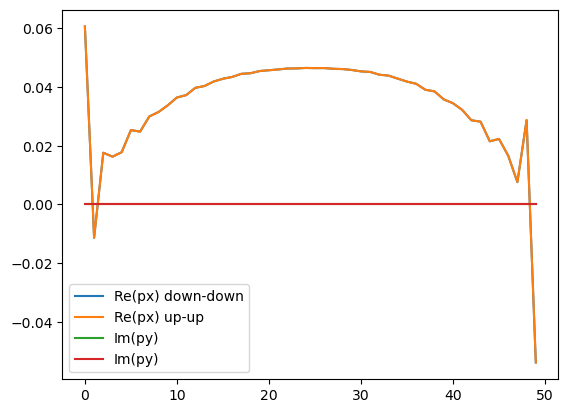

In [26]:
# plt.plot(np.real(Fx_p - Fx_m)/2, label='Re(px)')
plt.plot(np.real(Fddx_p - Fddx_m)/2, label='Re(px) down-down')
plt.plot(np.real(Fuux_p - Fuux_m)/2, label='Re(px) up-up')
plt.plot(np.imag(Fdd_yplus - Fdd_ymin)/2, label='Im(py)')
plt.plot(np.imag(Fuu_yplus - Fuu_ymin)/2, label='Im(py)')

# plt.plot(np.imag(F_yplus - F_ymin)/2, label='Im(py)')
# plt.plot(np.abs(F0), label='on-site')
# plt.plot(np.real(Fx_p + Fx_m - F_yplus - F_ymin)/4, label='d-wave')
# plt.plot(np.real(Fx_p + Fx_m + F_yplus + F_ymin)/4, label='extended-s')
plt.legend()

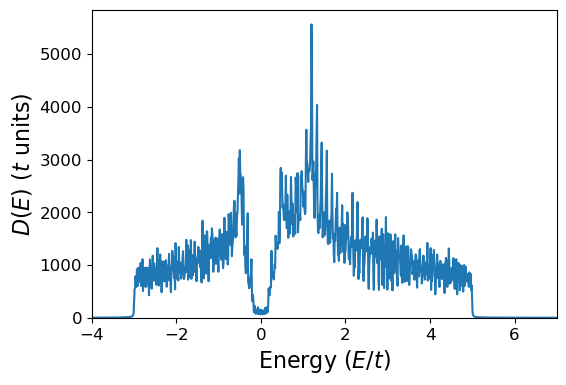

In [18]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.0051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [19]:
print(H.free_energy(0))

-9404.56524015215


In [20]:
# %prun H.dos(energies, eta=1e-3)